In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import shap
import warnings
warnings.filterwarnings('ignore')

# Load data
file_path = '/content/drive/MyDrive/Machine Learning/TrainDataStudy1.csv'
df = pd.read_csv(file_path)

print("Dataset Info:")
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum()}")
print("\nFirst few rows:")
print(df.head())

# Handle missing values
df_clean = df.dropna()
print(f"\nAfter removing missing values: {df_clean.shape}")

# Prepare features and target
X = df_clean[['Shell Thickness (mm)', 'Truss Diameter (mm)',
              'Length Variation (mm)', 'Width Variation (mm)']].values
y = df_clean['Young\'s Modulus (MPa)'].values

feature_names = ['Shell Thickness', 'Truss Diameter', 'Length Variation', 'Width Variation']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (needed for MLP and GPR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Dataset Info:
Shape: (80, 5)
Missing values: Shell Thickness (mm)     0
Truss Diameter (mm)      0
Length Variation (mm)    0
Width Variation (mm)     0
Young's Modulus (MPa)    5
dtype: int64

First few rows:
   Shell Thickness (mm)  Truss Diameter (mm)  Length Variation (mm)  \
0                   0.5                  1.0                    1.0   
1                   0.5                  1.3                    1.0   
2                   0.5                  1.6                    1.0   
3                   0.5                  1.9                    1.0   
4                   1.0                  1.0                    1.0   

   Width Variation (mm)  Young's Modulus (MPa)  
0                   1.0                  21.72  
1                   1.0                  23.37  
2                   1.0                  26.09  
3                   1.0                  30.19  
4                   1.0                  56.22  

After removing missing values: (75, 5)

Training samples: 60
Test sa

In [47]:
print("\n" + "="*50)
print("TRAINING MODELS")
print("="*50)

# Initialize models
models = {}

# 1. MLP (Neural Network) - requires scaled data
print("Training MLP...")
mlp = MLPRegressor(hidden_layer_sizes=(100, 50), alpha=0.01, random_state=42, max_iter=1000)
mlp.fit(X_train_scaled, y_train)
models['MLP'] = {'model': mlp, 'uses_scaled': True}

# 2. Gradient Boosting - works better with original data
print("Training Gradient Boosting...")
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
gb.fit(X_train, y_train)
models['Gradient Boosting'] = {'model': gb, 'uses_scaled': False}

# 3. Gaussian Process - requires scaled data
print("Training Gaussian Process...")
kernel = C(1.0) * RBF(1.0)
gpr = GaussianProcessRegressor(kernel=kernel, random_state=42)
gpr.fit(X_train_scaled, y_train)
models['Gaussian Process'] = {'model': gpr, 'uses_scaled': True}

print("All models trained!")


TRAINING MODELS
Training MLP...
Training Gradient Boosting...
Training Gaussian Process...
All models trained!


In [48]:
# Make Predictions
mlp_pred = mlp.predict(X_test_scaled)
gb_pred = gb.predict(X_test)
gpr_pred = gpr.predict(X_test_scaled)

# Evaluate Models
print("\n" + "="*50)
print("MODEL PERFORMANCE")
print("="*50)

models = ['MLP', 'Gradient Boosting', 'Gaussian Process']
predictions = [mlp_pred, gb_pred, gpr_pred]

results = []
for i, (model_name, pred) in enumerate(zip(models, predictions)):
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)

    results.append({
        'Model': model_name,
        'R²': r2,
        'RMSE': rmse,
        'MAE': mae
    })

    print(f"{model_name}:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print()

# Create results DataFrame
results_df = pd.DataFrame(results)
print("Summary:")
print(results_df)


MODEL PERFORMANCE
MLP:
  R² Score: 0.9560
  RMSE: 8.57
  MAE: 7.46

Gradient Boosting:
  R² Score: 0.9723
  RMSE: 6.80
  MAE: 4.41

Gaussian Process:
  R² Score: 0.9156
  RMSE: 11.87
  MAE: 7.99

Summary:
               Model        R²       RMSE       MAE
0                MLP  0.955959   8.572926  7.461737
1  Gradient Boosting  0.972262   6.803601  4.414532
2   Gaussian Process  0.915595  11.868257  7.992989


In [49]:
# Make Predictions
mlp_pred = mlp.predict(X_test_scaled)
gb_pred = gb.predict(X_test)
gpr_pred = gpr.predict(X_test_scaled)

# Evaluate Models - COMPREHENSIVE ACCURACY METRICS
print("\n" + "="*50)
print("MODEL PERFORMANCE - ALL ACCURACY METRICS")
print("="*50)

from sklearn.metrics import explained_variance_score, max_error
from scipy.stats import pearsonr

models = ['MLP', 'Gradient Boosting', 'Gaussian Process']
predictions = [mlp_pred, gb_pred, gpr_pred]
model_objects = [mlp, gb, gpr]

results = []
all_metrics = []

for i, (model_name, pred, model_obj) in enumerate(zip(models, predictions, model_objects)):
    # Calculate all accuracy metrics
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    explained_var = explained_variance_score(y_test, pred)
    max_err = max_error(y_test, pred)

    # Pearson correlation coefficient
    correlation, _ = pearsonr(y_test, pred)

    # Mean Absolute Percentage Error (MAPE)
    mape = np.mean(np.abs((y_test - pred) / y_test)) * 100

    # Accuracy percentage (custom metric for regression)
    # Using tolerance approach - within 10% of actual value
    tolerance = 0.10
    within_tolerance = np.abs((y_test - pred) / y_test) <= tolerance
    accuracy_10pct = np.mean(within_tolerance) * 100

    # Training set predictions for comparison
    if model_name == 'MLP':
        train_pred = model_obj.predict(X_train_scaled)
    elif model_name == 'Gaussian Process':
        train_pred = model_obj.predict(X_train_scaled)
    else:
        train_pred = model_obj.predict(X_train)

    train_r2 = r2_score(y_train, train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))

    # Store results
    results.append({
        'Model': model_name,
        'Test_R²': r2,
        'Train_R²': train_r2,
        'Test_RMSE': rmse,
        'Train_RMSE': train_rmse,
        'MAE': mae,
        'MAPE_%': mape,
        'Accuracy_10%': accuracy_10pct,
        'Correlation': correlation,
        'Explained_Var': explained_var
    })

    # Detailed metrics for each model
    all_metrics.append({
        'Model': model_name,
        'R² Score': r2,
        'RMSE': rmse,
        'MAE': mae,
        'MSE': mse,
        'MAPE (%)': mape,
        'Max Error': max_err,
        'Explained Variance': explained_var,
        'Correlation': correlation,
        'Accuracy (±10%)': accuracy_10pct,
        'Train R²': train_r2,
        'Overfitting (R² diff)': train_r2 - r2
    })

    print(f"{model_name} - DETAILED ACCURACY:")
    print(f"  R² Score (Test): {r2:.4f}")
    print(f"  R² Score (Train): {train_r2:.4f}")
    print(f"  Overfitting Check: {train_r2 - r2:.4f} (lower is better)")
    print(f"  RMSE (Test): {rmse:.2f} MPa")
    print(f"  RMSE (Train): {train_rmse:.2f} MPa")
    print(f"  MAE: {mae:.2f} MPa")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  Accuracy (±10%): {accuracy_10pct:.1f}%")
    print(f"  Correlation: {correlation:.4f}")
    print(f"  Explained Variance: {explained_var:.4f}")
    print(f"  Max Error: {max_err:.2f} MPa")
    print("-" * 40)

# Create comprehensive results DataFrame
results_df = pd.DataFrame(results)
all_metrics_df = pd.DataFrame(all_metrics)

print("\nCOMPREHENSIVE ACCURACY SUMMARY:")
print("="*60)
print(results_df.round(4))

print("\nALL METRICS DETAILED:")
print("="*60)
for metric_dict in all_metrics:
    print(f"\n{metric_dict['Model']}:")
    for key, value in metric_dict.items():
        if key != 'Model':
            if isinstance(value, float):
                print(f"  {key}: {value:.4f}")
            else:
                print(f"  {key}: {value}")

# Ranking models by different metrics
print("\n" + "="*60)
print("MODEL RANKINGS BY DIFFERENT METRICS")
print("="*60)

ranking_metrics = ['R² Score', 'RMSE', 'MAE', 'MAPE (%)', 'Accuracy (±10%)', 'Correlation']
for metric in ranking_metrics:
    if metric in ['RMSE', 'MAE', 'MAPE (%)', 'Max Error']:
        # Lower is better
        sorted_models = sorted(all_metrics, key=lambda x: x[metric])
        print(f"\n{metric} (Lower is Better):")
    else:
        # Higher is better
        sorted_models = sorted(all_metrics, key=lambda x: x[metric], reverse=True)
        print(f"\n{metric} (Higher is Better):")

    for i, model in enumerate(sorted_models, 1):
        print(f"  {i}. {model['Model']}: {model[metric]:.4f}")

# Best model overall
print("\n" + "="*60)
print("BEST MODEL RECOMMENDATION")
print("="*60)

# Score each model based on multiple metrics (normalized)
model_scores = {}
for model_dict in all_metrics:
    model_name = model_dict['Model']
    score = 0

    # R² Score (40% weight)
    score += model_dict['R² Score'] * 0.4

    # Accuracy ±10% (30% weight)
    score += (model_dict['Accuracy (±10%)'] / 100) * 0.3

    # Inverse RMSE (20% weight) - normalize by dividing by max RMSE
    max_rmse = max([m['RMSE'] for m in all_metrics])
    score += (1 - model_dict['RMSE'] / max_rmse) * 0.2

    # Low overfitting (10% weight)
    overfitting_penalty = max(0, model_dict['Overfitting (R² diff)'])
    score += max(0, (0.1 - overfitting_penalty)) * 0.1

    model_scores[model_name] = score

best_model = max(model_scores, key=model_scores.get)
print(f"RECOMMENDED MODEL: {best_model}")
print(f"Overall Score: {model_scores[best_model]:.4f}")

print("\nModel Scores:")
for model, score in sorted(model_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"  {model}: {score:.4f}")


MODEL PERFORMANCE - ALL ACCURACY METRICS
MLP - DETAILED ACCURACY:
  R² Score (Test): 0.9560
  R² Score (Train): 0.9923
  Overfitting Check: 0.0364 (lower is better)
  RMSE (Test): 8.57 MPa
  RMSE (Train): 3.27 MPa
  MAE: 7.46 MPa
  MAPE: 21.66%
  Accuracy (±10%): 46.7%
  Correlation: 0.9884
  Explained Variance: 0.9706
  Max Error: 14.22 MPa
----------------------------------------
Gradient Boosting - DETAILED ACCURACY:
  R² Score (Test): 0.9723
  R² Score (Train): 1.0000
  Overfitting Check: 0.0277 (lower is better)
  RMSE (Test): 6.80 MPa
  RMSE (Train): 0.19 MPa
  MAE: 4.41 MPa
  MAPE: 11.81%
  Accuracy (±10%): 66.7%
  Correlation: 0.9889
  Explained Variance: 0.9777
  Max Error: 17.74 MPa
----------------------------------------
Gaussian Process - DETAILED ACCURACY:
  R² Score (Test): 0.9156
  R² Score (Train): 1.0000
  Overfitting Check: 0.0844 (lower is better)
  RMSE (Test): 11.87 MPa
  RMSE (Train): 0.00 MPa
  MAE: 7.99 MPa
  MAPE: 11.38%
  Accuracy (±10%): 53.3%
  Correlation

In [50]:
# Manual Prediction
print("\n" + "="*50)
print("MANUAL PREDICTION EXAMPLE")
print("="*50)

def manual_predict(shell_thick, truss_diam, length_var, width_var):
    input_data = np.array([[shell_thick, truss_diam, length_var, width_var]])
    input_scaled = scaler.transform(input_data)

    mlp_result = mlp.predict(input_scaled)[0]
    gb_result = gb.predict(input_data)[0]
    gpr_result = gpr.predict(input_scaled)[0]

    print(f"Input: Shell={shell_thick}, Truss={truss_diam}, Length={length_var}, Width={width_var}")
    print(f"MLP Prediction: {mlp_result:.2f} MPa")
    print(f"Gradient Boosting: {gb_result:.2f} MPa")
    print(f"Gaussian Process: {gpr_result:.2f} MPa")

    return mlp_result, gb_result, gpr_result

# Example prediction
manual_predict(0.5, 1.2, 1.0, 1.0)


MANUAL PREDICTION EXAMPLE
Input: Shell=0.5, Truss=1.2, Length=1.0, Width=1.0
MLP Prediction: 27.38 MPa
Gradient Boosting: 23.49 MPa
Gaussian Process: 23.69 MPa


(np.float64(27.38297408442135),
 np.float64(23.491750438998146),
 np.float64(23.685922286442025))

In [51]:
# Batch Prediction
print("\n" + "="*50)
print("BATCH PREDICTION EXAMPLE")
print("="*50)

batch_data = [
    [0.5, 1.0, 1.0, 1.0],
    [1.0, 1.0, 1.0, 1.0],
    [0.5, 1.2, 1.0, 1.0]
]

batch_array = np.array(batch_data)
batch_scaled = scaler.transform(batch_array)

batch_mlp = mlp.predict(batch_scaled)
batch_gb = gb.predict(batch_array)
batch_gpr = gpr.predict(batch_scaled)

batch_results = pd.DataFrame(batch_data, columns=feature_names)
batch_results['MLP_Prediction'] = batch_mlp
batch_results['GB_Prediction'] = batch_gb
batch_results['GPR_Prediction'] = batch_gpr

print("Batch Prediction Results:")
print(batch_results.round(2))


BATCH PREDICTION EXAMPLE
Batch Prediction Results:
   Shell Thickness  Truss Diameter  Length Variation  Width Variation  \
0              0.5             1.0               1.0              1.0   
1              1.0             1.0               1.0              1.0   
2              0.5             1.2               1.0              1.0   

   MLP_Prediction  GB_Prediction  GPR_Prediction  
0           31.64          24.02           22.38  
1           63.24          59.50           57.46  
2           27.38          23.49           23.69  


In [52]:
# Prediction with Confidence (Enhanced Version)
print("\n" + "="*50)
print("PREDICTION WITH CONFIDENCE")
print("="*50)

# Convert arrays to DataFrames for easier indexing
X_train_df = pd.DataFrame(X_train, columns=feature_names)
y_train_series = pd.Series(y_train)

def predict_with_confidence(shell_thickness, truss_diameter, length_variation, width_variation):
    # Create input data point
    input_data = pd.DataFrame({
        'Shell Thickness (mm)': [shell_thickness],
        'Truss Diameter (mm)': [truss_diameter],
        'Length Variation (mm)': [length_variation],
        'Width Variation (mm)': [width_variation]
    })

    # Scale the input
    input_scaled = scaler.transform(input_data)
    input_original = input_data.values

    print(f"Input Parameters:")
    print(f"  Shell Thickness: {shell_thickness} mm")
    print(f"  Truss Diameter: {truss_diameter} mm")
    print(f"  Length Variation: {length_variation} mm")
    print(f"  Width Variation: {width_variation} mm")
    print("-" * 50)

    # Get predictions from all models
    mlp_pred = mlp.predict(input_scaled)[0]
    gb_pred = gb.predict(input_original)[0]
    gpr_pred, gpr_std = gpr.predict(input_scaled, return_std=True)
    gpr_pred = gpr_pred[0]
    gpr_std = gpr_std[0]

    print("MODEL PREDICTIONS:")
    print(f"  MLP: {mlp_pred:.2f} MPa")
    print(f"  Gradient Boosting: {gb_pred:.2f} MPa")
    print(f"  Gaussian Process: {gpr_pred:.2f} ± {1.96*gpr_std:.2f} MPa")

    # Ensemble prediction
    ensemble_pred = np.mean([mlp_pred, gb_pred, gpr_pred])
    ensemble_std = np.std([mlp_pred, gb_pred, gpr_pred])

    print(f"  Ensemble Average: {ensemble_pred:.2f} ± {1.96*ensemble_std:.2f} MPa")
    print()

    # Find similar cases in training data for confidence estimation
    distances = np.sqrt(np.sum((X_train_scaled - input_scaled)**2, axis=1))
    nearest_indices = np.argsort(distances)[:5]  # 5 nearest neighbors

    similar_cases = X_train_df.iloc[nearest_indices]
    similar_targets = y_train_series.iloc[nearest_indices]

    # Calculate expected error based on similar cases
    expected_error_mlp = np.mean(np.abs(similar_targets - mlp_pred))
    expected_error_gb = np.mean(np.abs(similar_targets - gb_pred))
    expected_error_ensemble = np.mean(np.abs(similar_targets - ensemble_pred))

    print("CONFIDENCE ANALYSIS:")
    print(f"  MLP Confidence Range: {mlp_pred-expected_error_mlp:.2f} to {mlp_pred+expected_error_mlp:.2f} MPa")
    print(f"  GB Confidence Range: {gb_pred-expected_error_gb:.2f} to {gb_pred+expected_error_gb:.2f} MPa")
    print(f"  GPR 95% Interval: {gpr_pred-1.96*gpr_std:.2f} to {gpr_pred+1.96*gpr_std:.2f} MPa")
    print(f"  Ensemble Range: {ensemble_pred-expected_error_ensemble:.2f} to {ensemble_pred+expected_error_ensemble:.2f} MPa")
    print()

    # Show similar cases
    print("MOST SIMILAR CASES IN TRAINING DATA:")
    for i, idx in enumerate(nearest_indices):
        case = similar_cases.iloc[i]
        target = similar_targets.iloc[i]
        distance = distances[idx]
        print(f"  Case {i+1} (distance: {distance:.3f}):")
        print(f"    Shell: {case[feature_names[0]]:.1f}, Truss: {case[feature_names[1]]:.1f}, "
              f"Length: {case[feature_names[2]]:.1f}, Width: {case[feature_names[3]]:.1f}")
        print(f"    Young's Modulus: {target:.2f} MPa")

    return {
        'mlp_pred': mlp_pred,
        'gb_pred': gb_pred,
        'gpr_pred': gpr_pred,
        'gpr_std': gpr_std,
        'ensemble_pred': ensemble_pred,
        'ensemble_std': ensemble_std,
        'expected_errors': {
            'mlp': expected_error_mlp,
            'gb': expected_error_gb,
            'ensemble': expected_error_ensemble
        }
    }

# Example prediction with confidence
result = predict_with_confidence(0.5, 1.2, 1.0, 1.0)


PREDICTION WITH CONFIDENCE
Input Parameters:
  Shell Thickness: 0.5 mm
  Truss Diameter: 1.2 mm
  Length Variation: 1.0 mm
  Width Variation: 1.0 mm
--------------------------------------------------
MODEL PREDICTIONS:
  MLP: 27.38 MPa
  Gradient Boosting: 23.49 MPa
  Gaussian Process: 23.69 ± 0.32 MPa
  Ensemble Average: 24.85 ± 3.51 MPa

CONFIDENCE ANALYSIS:
  MLP Confidence Range: 16.86 to 37.91 MPa
  GB Confidence Range: 12.71 to 34.28 MPa
  GPR 95% Interval: 23.37 to 24.00 MPa
  Ensemble Range: 14.34 to 35.36 MPa

MOST SIMILAR CASES IN TRAINING DATA:
  Case 1 (distance: 0.303):
    Shell: 0.5, Truss: 1.3, Length: 1.0, Width: 1.0
    Young's Modulus: 23.37 MPa
  Case 2 (distance: 0.968):
    Shell: 1.0, Truss: 1.3, Length: 1.0, Width: 1.0
    Young's Modulus: 58.33 MPa
  Case 3 (distance: 1.211):
    Shell: 0.5, Truss: 1.6, Length: 1.0, Width: 1.0
    Young's Modulus: 26.09 MPa
  Case 4 (distance: 1.349):
    Shell: 0.5, Truss: 1.3, Length: 1.2, Width: 1.0
    Young's Modulus: 32.


SHAP ANALYSIS
Analyzing Gradient Boosting with SHAP...
Feature Importance (SHAP):
            Feature  SHAP_Importance
0   Shell Thickness        31.897578
3   Width Variation        13.555781
1    Truss Diameter         6.542265
2  Length Variation         4.902694

CREATING VISUALIZATIONS


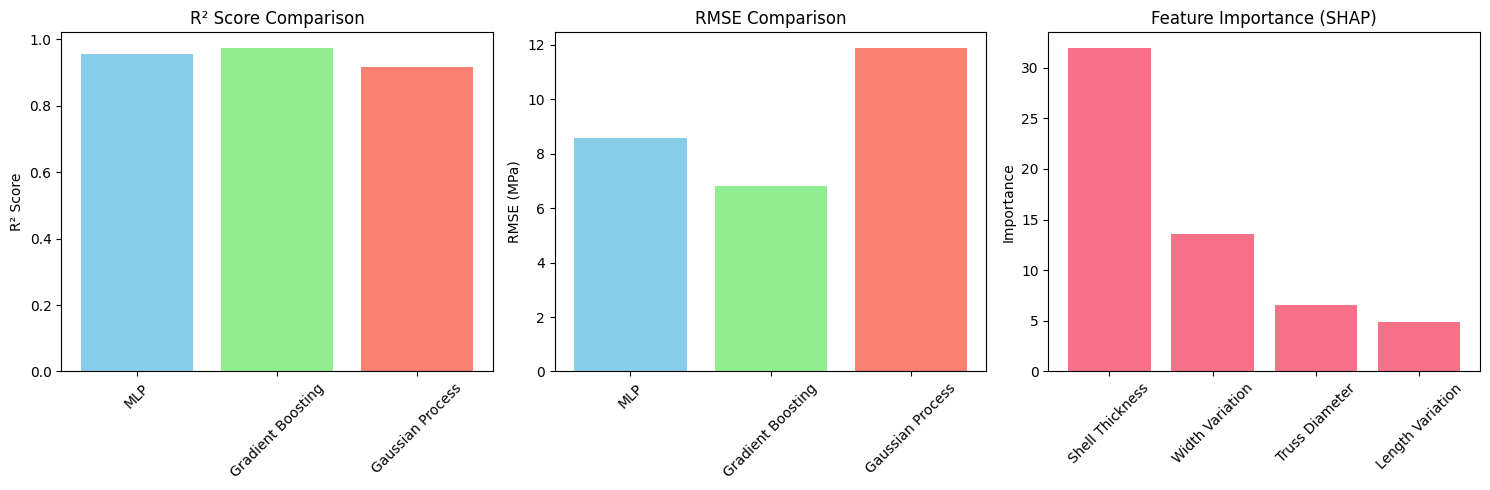

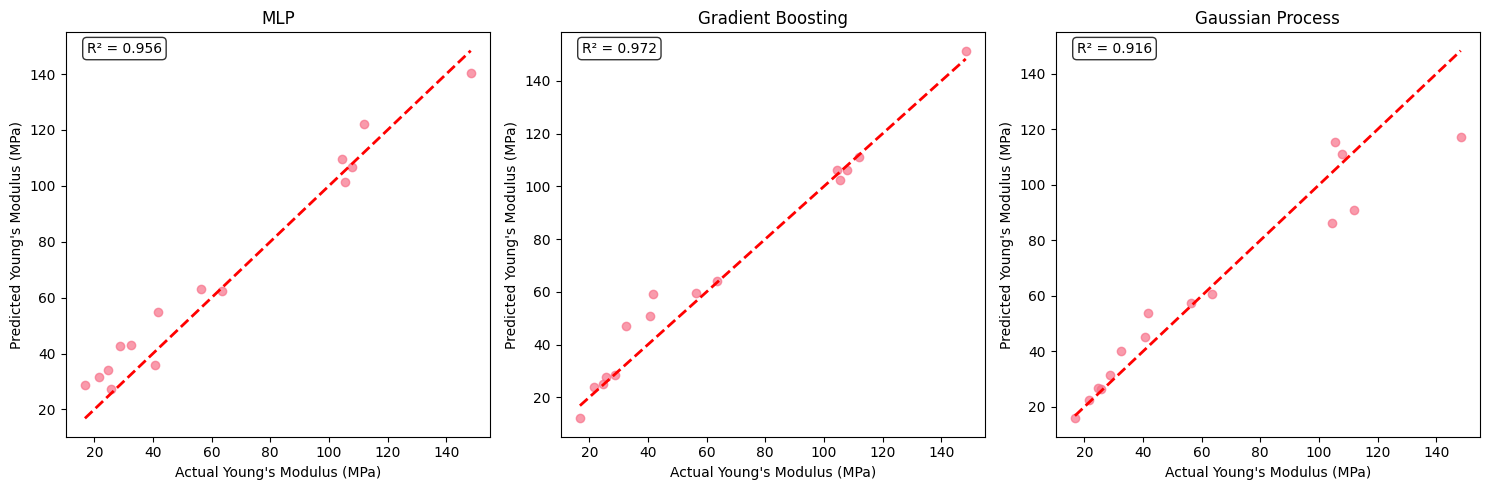

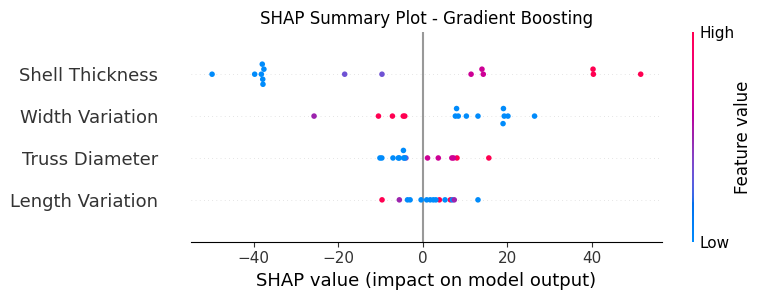


ANALYSIS COMPLETE!
Best model based on R² score: Gradient Boosting
Most important feature: Shell Thickness


In [53]:
# SHAP Analysis
print("\n" + "="*50)
print("SHAP ANALYSIS")
print("="*50)

# SHAP for Gradient Boosting
print("Analyzing Gradient Boosting with SHAP...")
explainer_gb = shap.TreeExplainer(gb)
shap_values_gb = explainer_gb.shap_values(X_test)

# Feature importance
feature_importance = np.abs(shap_values_gb).mean(0)
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_Importance': feature_importance
}).sort_values('SHAP_Importance', ascending=False)

print("Feature Importance (SHAP):")
print(importance_df)

# Visualizations
print("\n" + "="*50)
print("CREATING VISUALIZATIONS")
print("="*50)

# 1. Model Performance Comparison
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
r2_scores = [metric['R² Score'] for metric in all_metrics]
plt.bar(models, r2_scores, color=['skyblue', 'lightgreen', 'salmon'])
plt.title('R² Score Comparison')
plt.ylabel('R² Score')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
rmse_scores = [metric['RMSE'] for metric in all_metrics]
plt.bar(models, rmse_scores, color=['skyblue', 'lightgreen', 'salmon'])
plt.title('RMSE Comparison')
plt.ylabel('RMSE (MPa)')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
plt.bar(importance_df['Feature'], importance_df['SHAP_Importance'])
plt.title('Feature Importance (SHAP)')
plt.ylabel('Importance')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 2. Predictions vs Actual
plt.figure(figsize=(15, 5))

for i, (model_name, pred) in enumerate(zip(models, predictions)):
    plt.subplot(1, 3, i+1)
    plt.scatter(y_test, pred, alpha=0.7)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual Young\'s Modulus (MPa)')
    plt.ylabel('Predicted Young\'s Modulus (MPa)')
    plt.title(f'{model_name}')

    r2 = r2_score(y_test, pred)
    plt.text(0.05, 0.95, f'R² = {r2:.3f}', transform=plt.gca().transAxes,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# 3. SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_gb, X_test, feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot - Gradient Boosting')
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("ANALYSIS COMPLETE!")
print("="*50)
print("Best model based on R² score:", models[np.argmax(r2_scores)])
print("Most important feature:", importance_df.iloc[0]['Feature'])


--- Gradient Boosting Performance ---
MAE: 3.69
RMSE: 5.19
R² Score: 0.98
Accuracy: 97.20%


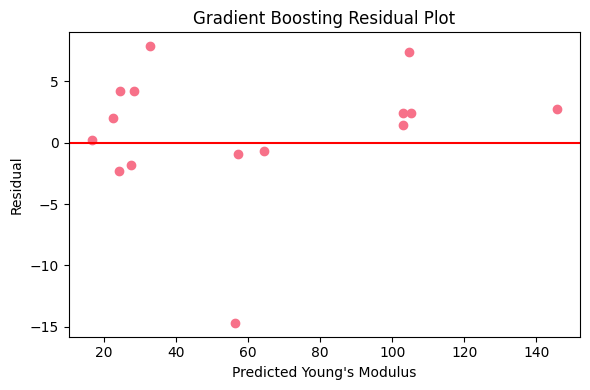

In [54]:
# === Gradient Boosting Regressor ===
from sklearn.ensemble import GradientBoostingRegressor

# Train Gradient Boosting on log-transformed target
y_log = np.log1p(y)
X_train_gb, X_test_gb, y_train_gb, y_test_gb = train_test_split(X, y_log, test_size=0.2, random_state=42)
X_train_gb_scaled = scaler.fit_transform(X_train_gb)
X_test_gb_scaled = scaler.transform(X_test_gb)

gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)
gb.fit(X_train_gb_scaled, y_train_gb)

# Predictions and inverse transform
y_pred_gb_log = gb.predict(X_test_gb_scaled)
y_pred_gb = np.expm1(y_pred_gb_log)
y_test_gb_true = np.expm1(y_test_gb)

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mse_gb = mean_squared_error(y_test_gb_true, y_pred_gb)
mae_gb = mean_absolute_error(y_test_gb_true, y_pred_gb)
r2_gb = r2_score(y_test_gb_true, y_pred_gb)
accuracy_gb = 100 * (1 - (mae_gb / (y_test_gb_true.max() - y_test_gb_true.min())))

print("\n--- Gradient Boosting Performance ---")
print(f"MAE: {mae_gb:.2f}")
print(f"RMSE: {np.sqrt(mse_gb):.2f}")
print(f"R² Score: {r2_gb:.2f}")
print(f"Accuracy: {accuracy_gb:.2f}%")

# Residual Plot
residuals_gb = y_test_gb_true - y_pred_gb
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_gb, residuals_gb)
plt.axhline(0, color='red')
plt.title("Gradient Boosting Residual Plot")
plt.xlabel("Predicted Young's Modulus")
plt.ylabel("Residual")
plt.tight_layout()
plt.savefig("gradient_boosting_residual.png")
plt.show()

In [55]:
# Function for manual prediction
def predict_youngs_modulus():
    print("\n=== Manual Prediction ===")
    print("Please enter the following values:")

    # Get input values for each feature
    shell_thickness = float(input("Shell Thickness (mm): "))
    truss_diameter = float(input("Truss Diameter (mm): "))
    length_variation = float(input("Length Variation (mm): "))
    width_variation = float(input("Width Variation (mm): "))

    # Create a dataframe with the input values
    input_data = pd.DataFrame({
        'Shell Thickness (mm)': [shell_thickness],
        'Truss Diameter (mm)': [truss_diameter],
        'Length Variation (mm)': [length_variation],
        'Width Variation (mm)': [width_variation]
    })

    # Scale the input data
    input_scaled = scaler.transform(input_data)

    # Make prediction
    prediction = gb.predict(input_scaled)[0] # Use the trained gb model instance

    # Inverse transform the prediction if log transformation was used
    prediction = np.expm1(prediction)


    print(f"\nPredicted Young's Modulus: {prediction:.2f} MPa")

    # Run the manual prediction function
predict_youngs_modulus()


=== Manual Prediction ===
Please enter the following values:
Shell Thickness (mm): 1
Truss Diameter (mm): 1
Length Variation (mm): 1
Width Variation (mm): 1

Predicted Young's Modulus: 57.13 MPa
